In [63]:
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()

True

In [64]:
class CricketState(TypedDict):
    runs:int
    balls:int
    fours:int
    six:int
    strikeRate:str
    ballPerBoundary:str
    summary:str

In [65]:
graph = StateGraph(CricketState)


In [66]:
def calsR(state:CricketState):
    sr = (state["runs"]/state["balls"] )* 100
    state["strikeRate"] = sr
    return {"strikeRate":sr}
def calbpb(state:CricketState):
    bpb = (state["balls"]-(state["fours"]+state["six"]))/state["balls"]

    state["ballPerBoundary"] = bpb
    return {"ballPerBoundary":bpb}
def summarise(state:CricketState):
    runs = state["runs"]
    balls = state["balls"]
    fours = state["fours"]
    six = state["six"]
    strikeRate = state["strikeRate"]

    summarise = f"The player played very well with runs of {runs} in {balls} . He striked with strike rate of {strikeRate} with fours : {fours} and sizes : {six}"
    state["summary"] = summarise

    return {"summary":summarise}

In [67]:
graph.add_node("calculateSR",calsR)
graph.add_node("calculateBPB",calbpb)
graph.add_node("summarise",summarise)


In [68]:
graph.add_edge(START,"calculateSR")
graph.add_edge(START,"calculateBPB")
graph.add_edge("calculateBPB","summarise")
graph.add_edge("calculateSR","summarise")
graph.add_edge("summarise",END)

In [69]:
workflow = graph.compile()

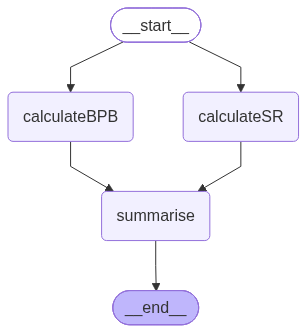

In [70]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())

In [72]:

initialData = {
    "runs":100,
    "balls":40,
    "fours":8,
    "six":6
}
results = workflow.invoke(initialData)

print(results["summary"])

The player played very well with runs of 100 in 40 . He striked with strike rate of 250.0 with fours : 8 and sizes : 6
